# Who builds the honest chatbot? A subsidy tender with a compliance audit
COMSCI/ECON 206 Computational Microeconomics · Autumn 2026 Session 1 · PS2 computational artifact · Muhan Chen

**Question.** A government pays one company, from a fixed grant, to build a non-sycophantic chatbot. It runs a second-price tender and then audits the winner. How strong must the audit be for the grant to buy honesty, and what happens to spending when the audit is weak?

**Run.** *Runtime → Run all.* Python standard library plus matplotlib (preinstalled in Colab). Deterministic: seed 206. All inputs are synthetic; no human data. The first code cell writes `chatbot_auction.py`, identical to the GitHub file, so the notebook needs no other file.

| Symbol | Meaning | Baseline |
|---|---|---|
| $n$ | companies per tender | 4 |
| $c_i$ | private cost of building the honest chatbot, i.i.d. $U[0,100]$ | — |
| $B$ | grant cap = fixed subsidy pool | 80 |
| $E$ | extra engagement revenue from a sycophantic chatbot | 30 |
| $k$ | extra tuning cost of making it sycophantic | 10 |
| $p$ | probability the regulator audits the winner | 0.5 (strong); 0.3 (weak) |
| $F$ | fine if the audit finds sycophancy | 50 |

In [1]:
%%writefile chatbot_auction.py
"""Who builds the honest chatbot? A second-price subsidy tender with a post-award compliance audit.

COMSCI/ECON 206 PS2 computational artifact (Muhan Chen). Python standard library only (matplotlib
is used only by the optional plotting helper). The rules, benchmark, and seeded random generator
are a line-by-line port of the Hugging Face game's game_logic.js, so a session code produces the
same costs, audits, and outcomes in both artifacts.
"""
from __future__ import annotations

import csv
import json
import math
import statistics
from dataclasses import asdict, dataclass, replace

MASK = 0xFFFFFFFF
RIVAL_NAMES = ("Rival A", "Rival B", "Rival C")
WEAK_AUDIT = 0.3


@dataclass(frozen=True)
class Config:
    n: int = 4                       # companies per auction
    cost_max: float = 100.0          # private cost of the honest chatbot ~ Uniform(0, cost_max)
    cap: float = 80.0                # fixed subsidy pool: maximum grant (reserve price)
    engagement_gain: float = 30.0    # E: extra engagement revenue from a sycophantic chatbot
    extra_tuning_cost: float = 10.0  # k: extra cost of tuning the chatbot to be sycophantic
    audit_prob: float = 0.5          # p: probability the regulator audits the winner
    fine: float = 50.0               # F: fine when the audit finds sycophancy
    rounds: int = 5                  # game rounds per session

    def __post_init__(self):
        if any(not math.isfinite(v) for v in asdict(self).values()):
            raise ValueError("Parameters must be finite.")
        if self.n < 2 or self.rounds < 1:
            raise ValueError("Need at least 2 companies and 1 round.")
        if not 0 < self.cap <= self.cost_max:
            raise ValueError("Cap must lie in (0, cost_max].")
        if not 0 <= self.audit_prob <= 1:
            raise ValueError("Audit probability must lie in [0, 1].")
        if min(self.engagement_gain, self.extra_tuning_cost, self.fine) < 0:
            raise ValueError("Gain, tuning cost, and fine must be nonnegative.")


BASELINE = Config()


def round1(x: float) -> float:
    """JavaScript Math.round(x * 10) / 10 (round half up), for exact parity with the game."""
    return math.floor(x * 10 + 0.5) / 10


def seed_from_code(code) -> int:
    """FNV-1a over UTF-16 code units, matching the game's seedFromCode."""
    data = str(code).encode("utf-16-le")
    h = 0x811C9DC5
    for i in range(0, len(data), 2):
        h ^= data[i] | (data[i + 1] << 8)
        h = (h * 0x01000193) & MASK
    return h


def mulberry32(seed: int):
    """32-bit mulberry32 generator returning floats in [0, 1), matching the game."""
    a = seed & MASK

    def imul(x, y):
        return (x * y) & MASK

    def rng() -> float:
        nonlocal a
        a = (a + 0x6D2B79F5) & MASK
        t = imul(a ^ (a >> 15), a | 1)
        t ^= (t + imul(t ^ (t >> 7), t | 61)) & MASK
        return ((t ^ (t >> 14)) & MASK) / 4294967296

    return rng


def cheat_gain(cfg: Config) -> float:
    """Net gain from shipping the sycophantic chatbot before any fine: E - k."""
    return cfg.engagement_gain - cfg.extra_tuning_cost


def expected_cheat_value(cfg: Config) -> float:
    """Expected value of cheating relative to complying: (E - k) - pF."""
    return cheat_gain(cfg) - cfg.audit_prob * cfg.fine


def audit_threshold(cfg: Config) -> float:
    """Audit probability at which a risk-neutral winner is indifferent: p* = (E - k) / F."""
    return cheat_gain(cfg) / cfg.fine if cfg.fine > 0 else math.inf


def rational_cheats(cfg: Config) -> bool:
    return expected_cheat_value(cfg) > 1e-9


def cheating_rent(cfg: Config) -> float:
    """Expected cheating rent a rational bidder passes into its bid; zero when audits deter cheating."""
    return max(0.0, expected_cheat_value(cfg))


def benchmark_bid_exact(cost: float, cfg: Config = BASELINE) -> float:
    """Weakly dominant bid in a reverse second-price tender: cost minus cheating rent, floored at 0."""
    return max(0.0, cost - cheating_rent(cfg))


def benchmark_bid(cost: float, cfg: Config = BASELINE) -> float:
    """Benchmark bid rounded to 0.1, as displayed and used by the game's computer rivals."""
    return round1(benchmark_bid_exact(cost, cfg))


def valid_bid(bid) -> bool:
    return isinstance(bid, (int, float)) and not isinstance(bid, bool) and math.isfinite(bid) and 0 <= bid <= 100


def run_auction(bids, cap: float, rounding: bool = True):
    """Reverse second-price tender: the lowest bid <= cap wins (ties go to the lower index, the player
    is index 0) and is paid min(second-lowest bid, cap). Returns (winner, payment); winner = -1 when
    no bid is at or below the cap."""
    if len(bids) < 2 or not all(valid_bid(b) for b in bids):
        raise ValueError("Bids must be at least two numbers between 0 and 100.")
    order = sorted(range(len(bids)), key=lambda i: (bids[i], i))
    winner = order[0]
    if bids[winner] > cap:
        return -1, 0.0
    payment = min(bids[order[1]], cap)
    return winner, round1(payment) if rounding else payment


def is_efficient(costs, winner: int, cap: float) -> bool:
    """True when the lowest-cost company with cost <= cap wins, or nobody wins because all costs exceed cap."""
    eligible = [i for i, c in enumerate(costs) if c <= cap]
    if not eligible:
        return winner == -1
    best = min(eligible, key=lambda i: (costs[i], i))
    return winner != -1 and costs[winner] == costs[best]


def round_profit(won: bool, payment: float, cost: float, cheat: bool, caught: bool,
                 cfg: Config = BASELINE, rounding: bool = True) -> float:
    if not won:
        return 0.0
    profit = payment - cost
    if cheat:
        profit += cheat_gain(cfg) - (cfg.fine if caught else 0.0)
    return round1(profit) if rounding else profit


def make_schedule(code, cfg: Config = BASELINE) -> dict:
    """Deterministic game schedule: costs and audits for a session code."""
    seed = seed_from_code(code)
    rng = mulberry32(seed)
    rounds = []
    for i in range(cfg.rounds):
        player_cost = round1(rng() * cfg.cost_max)
        rival_costs = [round1(rng() * cfg.cost_max) for _ in range(cfg.n - 1)]
        audited = rng() < cfg.audit_prob
        rounds.append({"round": i + 1, "playerCost": player_cost, "rivalCosts": rival_costs, "audited": audited})
    return {"code": str(code), "seed": seed, "rounds": rounds}


def resolve_round(r: dict, player_bid: float, player_cheats: bool, cfg: Config = BASELINE) -> dict:
    """One game round given the player's bid and comply/cheat choice (same fields as the game)."""
    rival_bids = [benchmark_bid(c, cfg) for c in r["rivalCosts"]]
    bids = [player_bid] + rival_bids
    costs = [r["playerCost"]] + r["rivalCosts"]
    winner, payment = run_auction(bids, cfg.cap)
    cheated = None
    if winner == 0:
        cheated = bool(player_cheats)
    elif winner > 0:
        cheated = rational_cheats(cfg)
    caught = cheated is True and r["audited"]
    bench = benchmark_bid(r["playerCost"], cfg)
    return {
        "round": r["round"],
        "playerCost": r["playerCost"],
        "playerBid": player_bid,
        "benchmarkBid": bench,
        "bidGap": round1(player_bid - bench),
        "rivalCosts": list(r["rivalCosts"]),
        "rivalBids": rival_bids,
        "winner": winner,
        "winnerName": "Nobody" if winner == -1 else "You" if winner == 0 else RIVAL_NAMES[winner - 1],
        "payment": payment,
        "efficient": is_efficient(costs, winner, cfg.cap),
        "cheated": cheated,
        "audited": None if winner == -1 else r["audited"],
        "caught": caught,
        "honestDelivered": None if winner == -1 else cheated is False,
        "playerProfit": round_profit(winner == 0, payment, r["playerCost"], cheated, caught, cfg),
    }


def simulate(cfg: Config = BASELINE, trials: int = 50000, seed: int = 206) -> dict:
    """Monte Carlo of the rational benchmark: all n companies bid the benchmark, the winner complies
    or cheats rationally, and the regulator audits with probability p. Uses unrounded bids and
    payments. The same seed gives every setting identical cost and audit draws."""
    if trials < 1:
        raise ValueError("trials must be positive.")
    rng = mulberry32(seed)
    cheats = rational_cheats(cfg)
    payments, profits = [], []
    awarded = efficient = honest = 0
    fines = 0.0
    for _ in range(trials):
        costs = [rng() * cfg.cost_max for _ in range(cfg.n)]
        audited = rng() < cfg.audit_prob
        bids = [benchmark_bid_exact(c, cfg) for c in costs]
        winner, payment = run_auction(bids, cfg.cap, rounding=False)
        efficient += is_efficient(costs, winner, cfg.cap)
        payments.append(payment)
        if winner == -1:
            continue
        awarded += 1
        caught = cheats and audited
        honest += not cheats
        fines += cfg.fine if caught else 0.0
        profits.append(round_profit(True, payment, costs[winner], cheats, caught, cfg, rounding=False))
    total_spend = sum(payments)
    return {
        "audit_prob": cfg.audit_prob,
        "trials": trials,
        "seed": seed,
        "winner_cheats": cheats,
        "cheating_rent": cheating_rent(cfg),
        "mean_spending": total_spend / trials,
        "sd_spending": statistics.pstdev(payments),
        "award_rate": awarded / trials,
        "efficient_rate": efficient / trials,
        "honest_delivery_rate": honest / trials,
        "spending_per_honest_chatbot": total_spend / honest if honest else None,
        "mean_winner_profit": statistics.fmean(profits) if profits else None,
        "mean_fines_collected": fines / trials,
    }


def compare_audits(cfg: Config = BASELINE, weak_p: float = WEAK_AUDIT, trials: int = 50000, seed: int = 206) -> dict:
    """The required comparison: the same second-price tender under a strong and a weak audit."""
    return {"strong": simulate(cfg, trials, seed), "weak": simulate(replace(cfg, audit_prob=weak_p), trials, seed)}


def audit_sweep(cfg: Config = BASELINE, probs=None, trials: int = 10000, seed: int = 206) -> list:
    """Parameter change: vary the audit probability p from 0 to 1."""
    probs = probs if probs is not None else [i / 20 for i in range(21)]
    rows = []
    for p in probs:
        s = simulate(replace(cfg, audit_prob=p), trials, seed)
        rows.append({k: s[k] for k in ("audit_prob", "cheating_rent", "mean_spending", "sd_spending",
                                       "honest_delivery_rate", "mean_winner_profit", "mean_fines_collected")})
    return rows


def expected_spending_exact(cfg: Config = BASELINE, steps: int = 20000) -> float:
    """Expected spending when audits deter cheating, by midpoint integration:
    E[min(C_(2), cap) * 1{C_(1) <= cap}]."""
    n, cmax, cap = cfg.n, cfg.cost_max, cfg.cap
    total, h = 0.0, cmax / steps
    for i in range(steps):
        x = (i + 0.5) * h
        f = x / cmax
        density = n * (n - 1) * f * (1 - f) ** (n - 2) / cmax  # second-lowest of n uniform costs
        total += min(x, cap) * density * h
    # If every cost exceeds the cap (then C_(2) > cap too) nothing is paid instead of cap.
    return total - cap * (1 - cap / cmax) ** n


def summarize_classroom(paths) -> dict:
    """Aggregates CSV records downloaded from the Hugging Face game (one file per player)."""
    rows = []
    for path in paths:
        with open(path, newline="", encoding="utf-8") as fh:
            rows.extend(csv.DictReader(fh))
    gaps = [float(r["bid_minus_benchmark"]) for r in rows]
    wins = [r for r in rows if r["winner"] == "You"]
    return {
        "players": len(paths),
        "rounds": len(rows),
        "mean_bid_gap": statistics.fmean(gaps) if gaps else None,
        "share_within_1_of_cost": sum(abs(g) <= 1 for g in gaps) / len(gaps) if gaps else None,
        "player_wins": len(wins),
        "player_cheat_rate": sum(r["winner_cheated"] == "true" for r in wins) / len(wins) if wins else None,
    }


def plot_results(cfg: Config, comparison: dict, sweep: list, out_dir: str = "outputs/figures"):
    """Three figures used in the paper and poster. Requires matplotlib."""
    import os
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    os.makedirs(out_dir, exist_ok=True)
    paths = []
    weak = replace(cfg, audit_prob=WEAK_AUDIT)
    strong_c, weak_c = "#14877d", "#b4461f"

    costs = [i / 10 for i in range(0, int(cfg.cost_max * 10) + 1)]
    fig, ax = plt.subplots(figsize=(5, 3.6))
    ax.plot(costs, [benchmark_bid_exact(c, cfg) for c in costs], color=strong_c,
            label=f"Strong audit (p = {cfg.audit_prob:g}): bid = cost")
    ax.plot(costs, [benchmark_bid_exact(c, weak) for c in costs], color=weak_c, ls="--",
            label=f"Weak audit (p = {WEAK_AUDIT:g}): bid = cost − {cheating_rent(weak):g}")
    ax.axhline(cfg.cap, color="grey", ls=":", lw=1, label=f"Grant cap = {cfg.cap:g}")
    ax.set_xlabel("Private cost of the honest chatbot")
    ax.set_ylabel("Rational bid")
    ax.set_title("Rational bids in the second-price tender")
    ax.legend(fontsize=8)
    fig.tight_layout()
    paths.append(os.path.join(out_dir, "fig1_bids.png"))
    fig.savefig(paths[-1], dpi=200)
    plt.close(fig)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.4, 3.4))
    labels = [f"Strong\np = {cfg.audit_prob:g}", f"Weak\np = {WEAK_AUDIT:g}"]
    s, w = comparison["strong"], comparison["weak"]
    ax1.bar(labels, [s["mean_spending"], w["mean_spending"]], color=[strong_c, weak_c])
    for i, v in enumerate([s["mean_spending"], w["mean_spending"]]):
        ax1.text(i, v + 0.8, f"{v:.1f}", ha="center", fontsize=9)
    ax1.set_ylabel("Mean government spending")
    ax1.set_ylim(0, 48)
    ax2.bar(labels, [100 * s["honest_delivery_rate"], 100 * w["honest_delivery_rate"]], color=[strong_c, weak_c])
    for i, v in enumerate([100 * s["honest_delivery_rate"], 100 * w["honest_delivery_rate"]]):
        ax2.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=9)
    ax2.set_ylabel("Honest chatbot delivered (%)")
    ax2.set_ylim(0, 115)
    fig.suptitle("A weak audit looks cheaper but buys flattery", fontsize=11)
    fig.tight_layout()
    paths.append(os.path.join(out_dir, "fig2_strong_vs_weak.png"))
    fig.savefig(paths[-1], dpi=200)
    plt.close(fig)

    fig, ax1 = plt.subplots(figsize=(5.4, 3.6))
    ax2 = ax1.twinx()
    ps = [r["audit_prob"] for r in sweep]
    ax1.plot(ps, [r["mean_spending"] for r in sweep], color=strong_c, label="Mean spending")
    ax2.step(ps, [r["honest_delivery_rate"] for r in sweep], where="post", color=weak_c, ls="--",
             label="Honest chatbot share")
    ax1.axvline(audit_threshold(cfg), color="grey", lw=1, ls=":")
    ax1.text(audit_threshold(cfg) + 0.01, 0.9, f"p* = {audit_threshold(cfg):.2f}", fontsize=8,
             transform=ax1.get_xaxis_transform())
    ax1.set_xlabel("Audit probability p")
    ax1.set_ylabel("Mean government spending")
    ax1.set_ylim(0, 1.25 * max(r["mean_spending"] for r in sweep))
    ax2.set_ylabel("Honest chatbot share")
    ax2.set_ylim(-0.05, 1.25)
    ax1.set_title("Audit strength: spending and honesty")
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, fontsize=7, loc="center right")
    fig.tight_layout()
    paths.append(os.path.join(out_dir, "fig3_audit_sweep.png"))
    fig.savefig(paths[-1], dpi=200)
    plt.close(fig)
    return paths


def main(out_path: str = "outputs/results.json", trials: int = 50000, seed: int = 206) -> dict:
    import os
    import platform

    cfg = BASELINE
    comparison = compare_audits(cfg, WEAK_AUDIT, trials, seed)
    results = {
        "python": platform.python_version(),
        "config": asdict(cfg),
        "audit_threshold": audit_threshold(cfg),
        "expected_cheat_value": expected_cheat_value(cfg),
        "expected_spending_exact": expected_spending_exact(cfg),
        "comparison": comparison,
        "audit_sweep": audit_sweep(cfg, seed=seed),
        "game_session_206": make_schedule("206", cfg),
    }
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    with open(out_path, "w", encoding="utf-8") as fh:
        json.dump(results, fh, indent=1)
    print(f"Python {results['python']} | seed {seed} | {trials} auctions per setting")
    print(f"p* = {results['audit_threshold']:.2f}; E[cheat - comply] at p = {cfg.audit_prob} is "
          f"{results['expected_cheat_value']:.1f}")
    print(f"Exact expected spending under a strong audit: {results['expected_spending_exact']:.2f}")
    print(f"{'metric':30s}{'strong p=0.5':>14s}{'weak p=0.3':>12s}")
    for key in ("cheating_rent", "mean_spending", "sd_spending", "efficient_rate", "honest_delivery_rate",
                "mean_winner_profit", "mean_fines_collected"):
        print(f"{key:30s}{comparison['strong'][key]:14.3f}{comparison['weak'][key]:12.3f}")
    print(f"Wrote {out_path}")
    return results


if __name__ == "__main__":
    main()

Overwriting chatbot_auction.py


In [2]:
import importlib, platform
import matplotlib
import chatbot_auction as ca
importlib.reload(ca)
print("Python", platform.python_version(), "| matplotlib", matplotlib.__version__)
print(ca.BASELINE)

Python 3.12.4 | matplotlib 3.8.4
Config(n=4, cost_max=100.0, cap=80.0, engagement_gain=30.0, extra_tuning_cost=10.0, audit_prob=0.5, fine=50.0, rounds=5)


## Model and solution concept
**Players.** $n$ risk-neutral AI companies; the government sets the rules. **Information.** Each company privately knows its own cost $c_i$; costs are independent draws from $U[0,100]$. $B, E, k, p, F$ are public.

**Timing.** (1) Nature draws costs. (2) Companies submit sealed bids $b_i\in[0,100]$, the grant they ask for. (3) The **lowest** bid $\le B$ wins and is paid the **second-lowest** bid, capped at $B$ (a reverse second-price tender); if every bid exceeds $B$, nothing is awarded. (4) The winner complies (builds honest, cost $c_i$) or cheats (builds sycophantic, cost $c_i+k$, extra revenue $E$). (5) Nature audits with probability $p$; an audited cheater pays $F$.

**Payoffs.** Loser: 0. Winner: $P-c_i$ if it complies; $P-c_i+(E-k)-F\cdot\mathbf 1[\text{audited}]$ if it cheats.

**Solution (backward induction).** Stage 4: the choice does not depend on rivals, so the winner cheats iff $E-k>pF$, i.e. iff $p<p^\ast=(E-k)/F=0.4$ (Becker 1968). The grant $P$ cancels out of this comparison. Stage 2 is a Bayesian game (private costs); in a second-price tender bidding one's effective cost $\max(0,\,c_i-\rho)$ is weakly dominant (Vickrey 1961), where $\rho=\max(0,E-k-pF)$ is the expected cheating rent. With a strong audit ($p=0.5$), $\rho=0$ and the benchmark is simply *bid your cost*. With a weak audit ($p=0.3$), $\rho=5$ and every company bids 5 below cost.

**Pseudocode (one tender).**
```
input: costs c[1..n], audit draw u, parameters (B, E, k, p, F)
rho   <- max(0, E - k - p*F)
bid_i <- max(0, c_i - rho)
w     <- argmin_i bid_i  (ties: lowest index); if bid_w > B: no award, stop
pay   <- min(second-lowest bid, B)
cheat <- (rho > 0);  caught <- cheat and (u < p)
record pay, efficient = (c_w is the lowest cost <= B), honest = not cheat,
       winner profit = pay - c_w + cheat*(E - k) - caught*F
```

In [3]:
cfg = ca.BASELINE
weak = ca.replace(cfg, audit_prob=ca.WEAK_AUDIT)
print(f"p* = (E-k)/F = {ca.audit_threshold(cfg):.2f}")
print(f"Strong audit p={cfg.audit_prob}: E[cheat]-E[comply] = {ca.expected_cheat_value(cfg):+.1f}, rent = {ca.cheating_rent(cfg):.1f}")
print(f"Weak audit   p={weak.audit_prob}: E[cheat]-E[comply] = {ca.expected_cheat_value(weak):+.1f}, rent = {ca.cheating_rent(weak):.1f}")
print(f"{'cost':>6} {'bid (strong)':>13} {'bid (weak)':>11}")
for c in (0, 3, 20, 40, 60, 79, 90):
    print(f"{c:>6} {ca.benchmark_bid(c, cfg):>13} {ca.benchmark_bid(c, weak):>11}")

p* = (E-k)/F = 0.40
Strong audit p=0.5: E[cheat]-E[comply] = -5.0, rent = 0.0
Weak audit   p=0.3: E[cheat]-E[comply] = +5.0, rent = 5.0
  cost  bid (strong)  bid (weak)
     0           0.0         0.0
     3           3.0         0.0
    20          20.0        15.0
    40          40.0        35.0
    60          60.0        55.0
    79          79.0        74.0
    90          90.0        85.0


## Comparison: the same tender under a strong and a weak audit
50,000 tenders per setting with the **same** cost and audit draws, so differences come from the audit alone. Metrics: mean and standard deviation of government spending, share funding the lowest-cost eligible company (efficiency), share delivering an honest chatbot, winner profit, and fines collected. `ca.main()` also writes every number to `outputs/results.json`.

In [4]:
results = ca.main()
comp = results["comparison"]

Python 3.12.4 | seed 206 | 50000 auctions per setting
p* = 0.40; E[cheat - comply] at p = 0.5 is -5.0
Exact expected spending under a strong audit: 39.73
metric                          strong p=0.5  weak p=0.3
cheating_rent                          0.000       5.000
mean_spending                         39.684      34.893
sd_spending                           19.729      19.875
efficient_rate                         1.000       0.991
honest_delivery_rate                   0.999       0.000
mean_winner_profit                    19.788      19.962
mean_fines_collected                   0.000      14.899
Wrote outputs/results.json


## Parameter change: sweep the audit probability
$p$ from 0 to 1 in steps of 0.05, 10,000 tenders per value.

In [5]:
print(f"{'p':>5} {'rent':>5} {'spending':>9} {'SD':>6} {'honest':>7} {'fines':>6}")
for r in results["audit_sweep"]:
    if r["audit_prob"] in (0.0, 0.2, 0.3, 0.35, 0.4, 0.5, 1.0):
        print(f"{r['audit_prob']:>5.2f} {r['cheating_rent']:>5.1f} {r['mean_spending']:>9.2f} "
              f"{r['sd_spending']:>6.2f} {r['honest_delivery_rate']:>7.3f} {r['mean_fines_collected']:>6.2f}")

    p  rent  spending     SD  honest  fines
 0.00  20.0     20.79  18.15   0.000   0.00
 0.20  10.0     29.62  19.61   0.000  10.10
 0.30   5.0     34.41  19.78   0.000  14.95
 0.35   2.5     36.83  19.74   0.000  17.41
 0.40   0.0     39.23  19.65   0.999   0.00
 0.50   0.0     39.23  19.65   0.999   0.00
 1.00   0.0     39.23  19.65   0.999   0.00


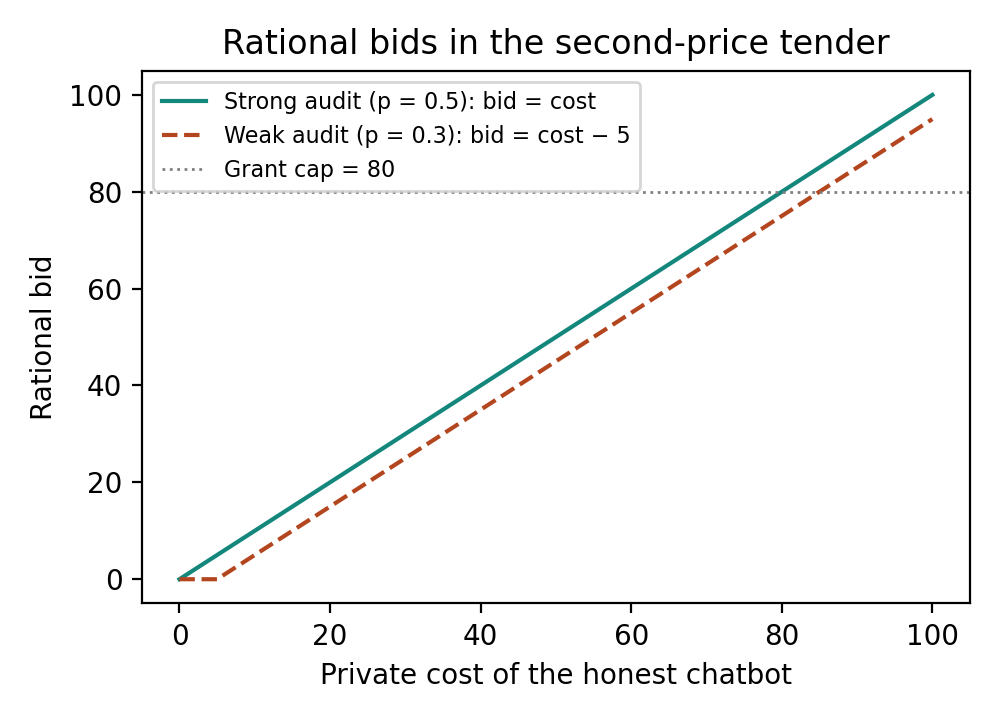

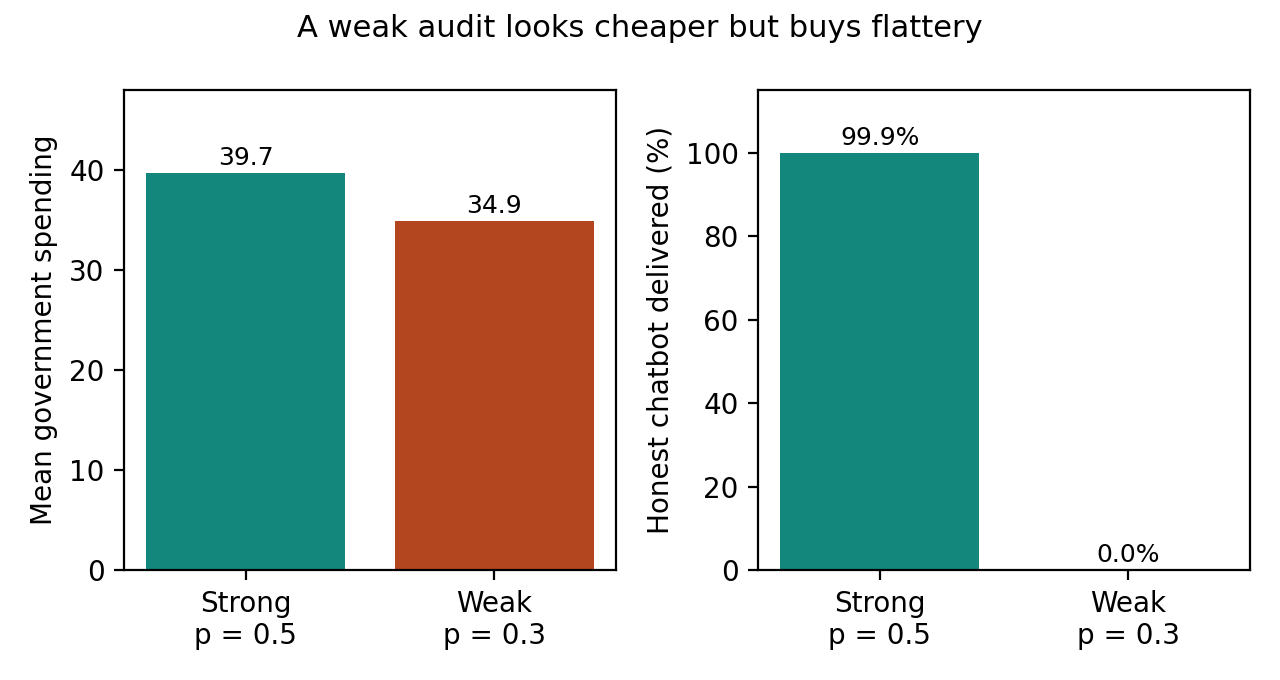

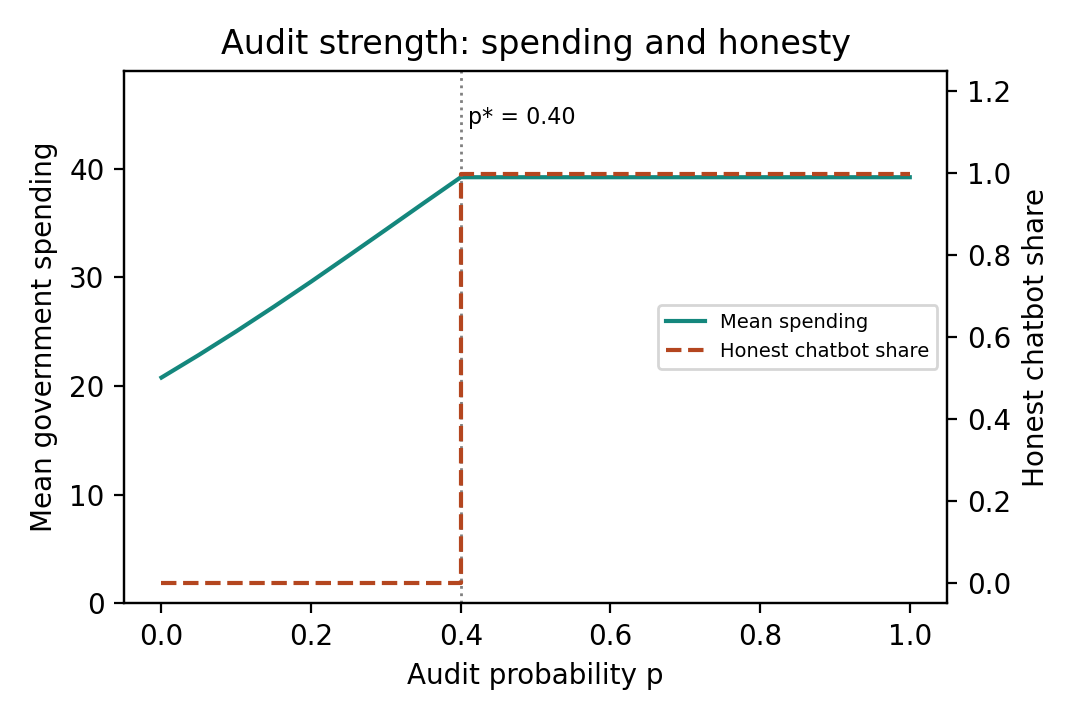

In [6]:
from IPython.display import Image, display
for path in ca.plot_results(cfg, comp, results["audit_sweep"]):
    display(Image(filename=path, width=460))

## Parity with the Hugging Face game
The game uses the same rules and the same seeded generator (mulberry32 seeded by an FNV-1a hash of the session code). Session code `206` below reproduces the costs, audits, and rival bids a player sees; `tests/js_fixture.json` in the repository stores the game's own output for automated comparison.

In [7]:
s = ca.make_schedule("206")
print("seed", s["seed"])
print(f"{'round':>5} {'your cost':>9} {'rival costs (= rival bids)':>28} {'audited':>8}")
for r in s["rounds"]:
    print(f"{r['round']:>5} {r['playerCost']:>9} {str(r['rivalCosts']):>28} {str(r['audited']):>8}")

seed 3186052587
round your cost   rival costs (= rival bids)  audited
    1       6.3            [38.9, 13.0, 2.3]    False
    2      49.8            [46.9, 57.9, 2.2]     True
    3      63.0           [44.5, 97.0, 30.1]     True
    4      87.5             [84.4, 4.5, 2.7]     True
    5      12.3           [98.8, 11.3, 38.5]     True


## Verification
Checks on the theory and the rules. The repository runs the full suite, including exact parity with the game: `python -m unittest discover -s tests -v`.

In [8]:
import math
assert abs(ca.audit_threshold(cfg) - 0.4) < 1e-12 and not ca.rational_cheats(cfg) and ca.rational_cheats(weak)
assert ca.benchmark_bid(40, cfg) == 40 and ca.benchmark_bid(40, weak) == 35
assert ca.run_auction([30, 50, 40, 90], 80) == (0, 40)
assert ca.run_auction([30, 85, 90, 95], 80) == (0, 80)
assert ca.run_auction([85, 81, 90, 95], 80) == (-1, 0.0)
# Truthful bidding is weakly dominant on a grid of rival bids.
for cost in (5, 40, 79, 85):
    for r1 in range(0, 101, 10):
        for r2 in range(0, 101, 10):
            pay = lambda b: (lambda w, p: p - cost if w == 0 else 0)(*ca.run_auction([b, r1, r2, 100], 80, False))
            assert all(pay(cost) >= pay(d) - 1e-9 for d in range(0, 101, 5))
# Simulated strong-audit spending lies within 4 standard errors of the exact value.
st = comp["strong"]
assert abs(st["mean_spending"] - results["expected_spending_exact"]) < 4 * st["sd_spending"] / math.sqrt(st["trials"])
# The weak audit is cheaper but delivers no honest chatbot.
assert comp["weak"]["mean_spending"] < st["mean_spending"] and comp["weak"]["honest_delivery_rate"] == 0
for bad in ([math.nan, 40], [-1, 40], [101, 40]):
    try:
        ca.run_auction(bad, 80)
    except ValueError:
        pass
    else:
        raise AssertionError("invalid bid accepted")
print("All checks passed.")

All checks passed.


## Classroom evidence (planned)
Players can download a CSV record from the Hugging Face game. Put the files in `data/classroom/` and rerun this cell to compare actual bids with the benchmark and the cheating rate among winners. Classroom play is exploratory evidence, not a population estimate.

In [9]:
import glob
paths = sorted(glob.glob("data/classroom/*.csv"))
if paths:
    print(ca.summarize_classroom(paths))
else:
    print("No classroom records yet; planned after the September 28 symposium.")

No classroom records yet; planned after the September 28 symposium.


## Results and research limits
Actual outputs above (seed 206; 50,000 tenders per setting; 10,000 per value in the sweep). These are model calculations, not observed firm or regulator behavior.

* **Strong audit ($p=0.5$).** Complying is rational ($E[\text{cheat}]-E[\text{comply}]=-5$), so every company bids its cost. Mean government spending is 39.68 (exact value 39.73). The lowest-cost eligible company wins essentially every tender, and an honest chatbot is delivered in 99.9% of tenders (in $0.2^4=0.16\%$ of tenders every cost exceeds the cap and nothing is awarded).
* **Weak audit ($p=0.3$).** Cheating pays ($+5$ in expectation), so every winner ships the flattering chatbot and the honest-delivery rate is 0. Spending *falls* to 34.89, and fines of about 14.90 per tender come in, because competition passes the expected cheating rent $\rho=5$ into lower bids. Winner profit barely changes (19.79 vs. 19.96): the rent goes to the government as lower prices, while users bear the flattery.
* **Parameter change.** The sweep shows a sharp switch at $p^\ast=0.4$: below it, honest delivery is 0 and spending falls with $p$ (20.79 at $p=0$, 34.41 at $p=0.3$); above it, nothing changes (39.23), so audits stronger than $p^\ast$ only add audit costs.
* **Project decision supported.** A grant for honest chatbots must come with an audit at $p \ge p^\ast$. A cheaper-than-expected tender is a warning sign that audits are too weak. Left unresolved: whether real bidders bid their cost and keep the promise (classroom evidence, planned).

**Limits.** Risk-neutral, symmetric companies with independent uniform costs; one tender; losing companies are passive; audits detect sycophancy perfectly; sycophancy is binary; $E$, $k$, $F$ are illustrative values, not estimates. Collusion, risk aversion, correlated costs, or imperfect audits could change both the bids and the threshold.

## Sources and AI assistance
Vickrey (1961), *Journal of Finance* 16(1):8–37, doi:10.1111/j.1540-6261.1961.tb02789.x. Becker (1968), *Journal of Political Economy* 76(2):169–217, doi:10.1086/259394. Harsanyi (1967), *Management Science* 14(3):159–182, doi:10.1287/mnsc.14.3.159.

An AI coding assistant (Cursor, Claude model) drafted the code, tests, and explanatory text on September 23 and 25, 2026, from the author's model decisions (a second-price tender, an extra tuning cost for sycophancy, a strong vs. weak audit comparison, baseline parameters). Saved outputs were produced by executing this notebook top to bottom in a fresh kernel. The author reviewed the model and reran the notebook in Colab.